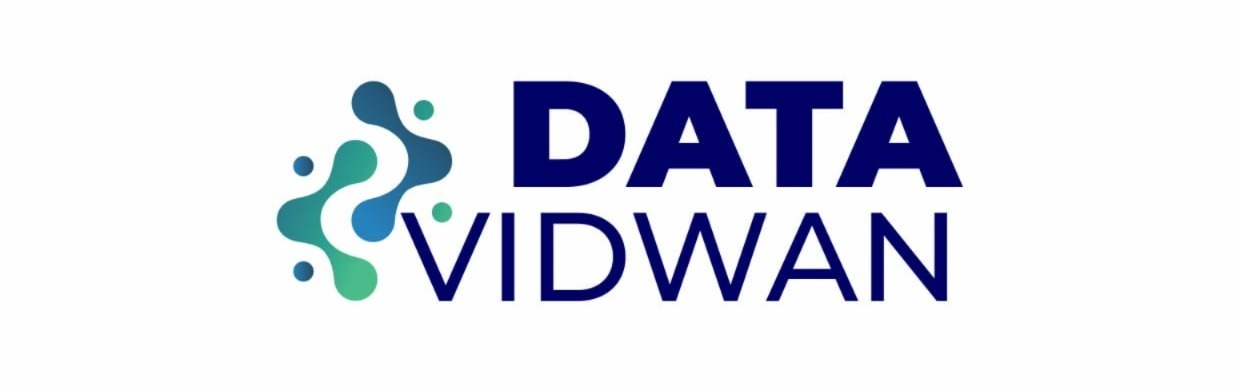

# **What is Multiple Linear Regression?**

- Multiple Linear Regression (MLR) is an extension of Simple Linear Regression.
In simple linear, we had one independent variable (X) and one dependent variable (Y). But in multiple linear, we have two or more independent variables (X₁, X₂, X₃, ...) that affect the dependent variable Y.

**Example:**

Imagine we want to predict the price of a house based on:
- Area(sqrt)
- Number of Bedrooms
- Age of House(in years)

So here:
- Dependent variable (Y) → Price
- Independent variables (X₁, X₂, X₃) → Area, Bedrooms, Age

**Mathematical Equation:**

Y = 𝛽0 + 𝛽1X1 + 𝛽2X2 +...+𝛽nXn+ 𝜀

Where:
- Y: Predicted value(e.g., price)
- 𝛽0: Intercept (value of Y when all X=0)
- 𝛽1, 𝛽2,...,𝛽n: Coefficients (how much Y changes when Xi changes)
- 𝜀: Error term (difference between predicted and actual)

**Immport Libraries**

In [1]:
import pandas as pd               # for data handling
import numpy as np                # for numerical operations
import matplotlib.pyplot as plt   # for visualization
import seaborn as sns             # for better visual plots
from sklearn.model_selection import train_test_split  # to split data
from sklearn.linear_model import LinearRegression      # model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score  # evaluation metrics

**Load Dataset**

In [2]:
from google.colab import files
uploaded = files.upload()

Saving house_price.csv to house_price.csv


In [3]:
df = pd.read_csv("house_price.csv")

# Display first few rows
df.head()

,area,bedrooms,age,price
0,1660,4,29,325613
1,4572,2,1,728826
2,3892,5,28,689354
3,1266,1,27,198808
4,4244,5,25,736210


In [ ]:
# Check info about dataset
df.info()

# Check statistical summary
df.describe()

# Check for missing values
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   area      1500 non-null   int64
 1   bedrooms  1500 non-null   int64
 2   age       1500 non-null   int64
 3   price     1500 non-null   int64
dtypes: int64(4)
memory usage: 47.0 KB


,0
area,0
bedrooms,0
age,0
price,0


**Feature Target**

In [ ]:
# Choose features and target
feature_cols = ["area", "bedrooms", "age"]   # adjust if your column names differ
target_col = "price"

X = df[feature_cols]
y = df[target_col]

**Split into train/test**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape

((1200, 3), (300, 3))

**Model Training**

In [ ]:
# Fit model
model = LinearRegression()
model.fit(X_train, y_train)

# Intercept & Coefficients
intercept = model.intercept_
coefs = pd.Series(model.coef_, index=X_train.columns)

print("Intercept (β0):", intercept)
print("\nCoefficients (β):")
print(coefs)

Intercept (β0): -755.0688625508337

Coefficients (β):
area          150.261317
bedrooms    25148.832537
age         -1036.700443
dtype: float64


| Term                                     | Meaning            | Explanation                                                                                            |
| ---------------------------------------- | ------------------ | ------------------------------------------------------------------------------------------------------ |
| **Intercept (β₀ = -755.07)**             | Base value         | It’s the predicted price when all X = 0 (not practically meaningful, but required mathematically).     |
| **area coefficient (β₁ = 150.26)**       | Slope for area     | For every extra 1 sqft area, house price increases by **= ₹150.26** (keeping other features constant). |
| **bedrooms coefficient (β₂ = 25148.83)** | Slope for bedrooms | Adding one more bedroom increases price by **= ₹25,148.83** (if area & age same).                      |
| **age coefficient (β₃ = -1036.70)**      | Negative impact    | For every extra year of age, price decreases by **= ₹1,036.70** (older houses cheaper).                |


**Final Model Equation**

price = -755.07 + 150.26(area) + 25148.83(bedrooms) - 1036.70(age)

**Predict the model**

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
r2  = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"R²:  {r2:.4f}")
print(f"MAE: {mae:,.2f}")
print(f"MSE: {mse:,.2f}")
print(f"RMSE:{rmse:,.2f}")

R²:  0.9964
MAE: 9,846.61
MSE: 130,254,821.72
RMSE:11,412.92


- R² value lies between 0 and 1, Closer to 1 = better fit.
- **MAE(Mean Absolute Error):**
  - tells the average absolute difference between actual and predicted prices.
  - So, on average, your predictions differ from the real price by around ₹ 9,846 only.
  - It’s a direct, easy-to-understand metric: Lower = Better.
- **MSE(Mean Squared Error):**
  - It squares each error and takes the mean.
  - Useful for penalizing large errors more heavily.
- **RMSE (Root Mean Squared Error):**
  - it's the square root of MSE - brings the error back to the original unit.

**Quick check: first 10 predictions vs actuals**

In [ ]:
comparison = pd.DataFrame({
    "Actual":    y_test.values[:10],
    "Predicted": y_pred[:10]
}).reset_index(drop=True)
print("\nSample predictions (first 10 rows):")
print(comparison)


Sample predictions (first 10 rows):
   Actual      Predicted
0  340227  339985.860296
1  369787  388608.797781
2  260934  245951.506935
3  396628  406495.404705
4  311304  291150.932258
5  686394  684717.822308
6  690275  680480.060196
7  169308  174064.868155
8  564979  581964.016492
9  274110  254213.638795


**Visualization - Actual vs Predicted**

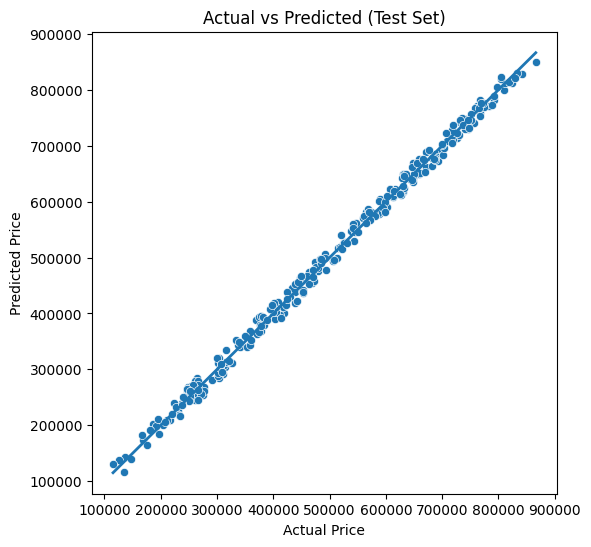

In [ ]:
plt.figure(figsize=(6,6))
sns.scatterplot(x=y_test, y=y_pred, s=35)
# ideal reference line (y = x)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], lw=2)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted (Test Set)")
plt.show()

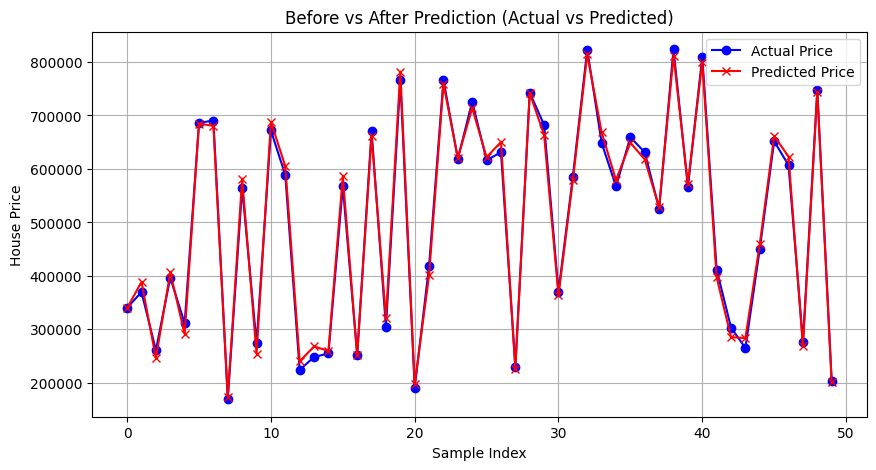

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(y_test.values[:50], label='Actual Price', color='blue', marker='o')
plt.plot(y_pred[:50], label='Predicted Price', color='red', marker='x')
plt.title("Before vs After Prediction (Actual vs Predicted)")
plt.xlabel("Sample Index")
plt.ylabel("House Price")
plt.legend()
plt.grid(True)
plt.show()

**Save Model**

In [ ]:
import pickle

# Save model as .pkl file
with open("Multiple_LinearRegression_Model.pkl", "wb") as file:
    pickle.dump(model, file)

print(" Model saved successfully as 'Multiple_LinearRegression_Model.pkl'")

 Model saved successfully as 'Multiple_LinearRegression_Model.pkl'
